In [1]:
import os
import sys
import torch
import numpy as np
import scipy.io
import h5py
import argparse
from random import SystemRandom

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.distributions.normal import Normal
from torch.distributions import kl_divergence

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from lib.utils import *
from lib.ProposeModel import *
from lib.BaselineModel import *

# Generative model for noisy data based on ODE
parser = argparse.ArgumentParser('Latent Neural Operator')
parser.add_argument('--niters', type=int, default=2000)
parser.add_argument('--batch_size', type=int, default=50)
parser.add_argument('--lr',  type=float, default=1e-2, help="Starting learning rate.")

parser.add_argument('--input_dim', type=int, default=1, help="Dimensionality of the input system.")
parser.add_argument('--rec_dims', type=int, default=32, help="Dimensionality of the recognition model (NO or RNN).")
parser.add_argument('--latents', type=int, default=32, help="Size of the latent state")
parser.add_argument('--gru_units', type=int, default=100, help="Number of units per layer in each of GRU update networks")
parser.add_argument('--rec_len', type=int, default=20, help="The length of observation data")
parser.add_argument('--n_traj_samples', type=int, default=5, help="The number of trajectory samples")
parser.add_argument('--noise_weight', type=float, default=0.2, help="Noise amplitude for generated traejctories")

if 'ipykernel' in sys.modules:
    args = parser.parse_args([])
else:
    args = parser.parse_args()
    
#experimentID = int(SystemRandom().random()*100000)+10000
experimentID = 10000 + 0
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
file_name = 'LNO'
ckpt_path = os.path.join("experiments/experiment_" + str(experimentID) + '.ckpt')


In [2]:
# read dataset
def read_data():
    dataset_GT = np.load('data/period.npy')
    dataset = dataset_GT.copy()
    noise = (np.random.sample(dataset.shape[:-1]) - 0.5)*2
    dataset[...,0] += args.noise_weight * noise
    
    train_size = int(dataset.shape[0] * 0.8)
    train_dataset = torch.tensor(dataset[:train_size])
    test_dataset = torch.tensor(dataset[train_size:])
    test_GT = dataset_GT[train_size:,:,:-1]
    
    print("dataset.shape:", dataset.shape)
    print("dataset_GT.shape", dataset_GT.shape)
    print("test_GT.shape", test_GT.shape)
    print("train_size:", train_size)
    return(train_dataset, test_dataset, test_GT)

train_dataset, test_dataset, test_GT = read_data()
args.input_dim = train_dataset.shape[-1] - 1

train_n = train_dataset.shape[0]
test_n = test_dataset.shape[0]
batch_size = min(args.batch_size, train_n)
train_dataloader = DataLoader(train_dataset.to(device), batch_size = args.batch_size, shuffle=True)
train_dataloader_iter = iter(train_dataloader)


dataset.shape: (3000, 100, 2)
dataset_GT.shape (3000, 100, 2)
test_GT.shape (600, 100, 1)
train_size: 2400


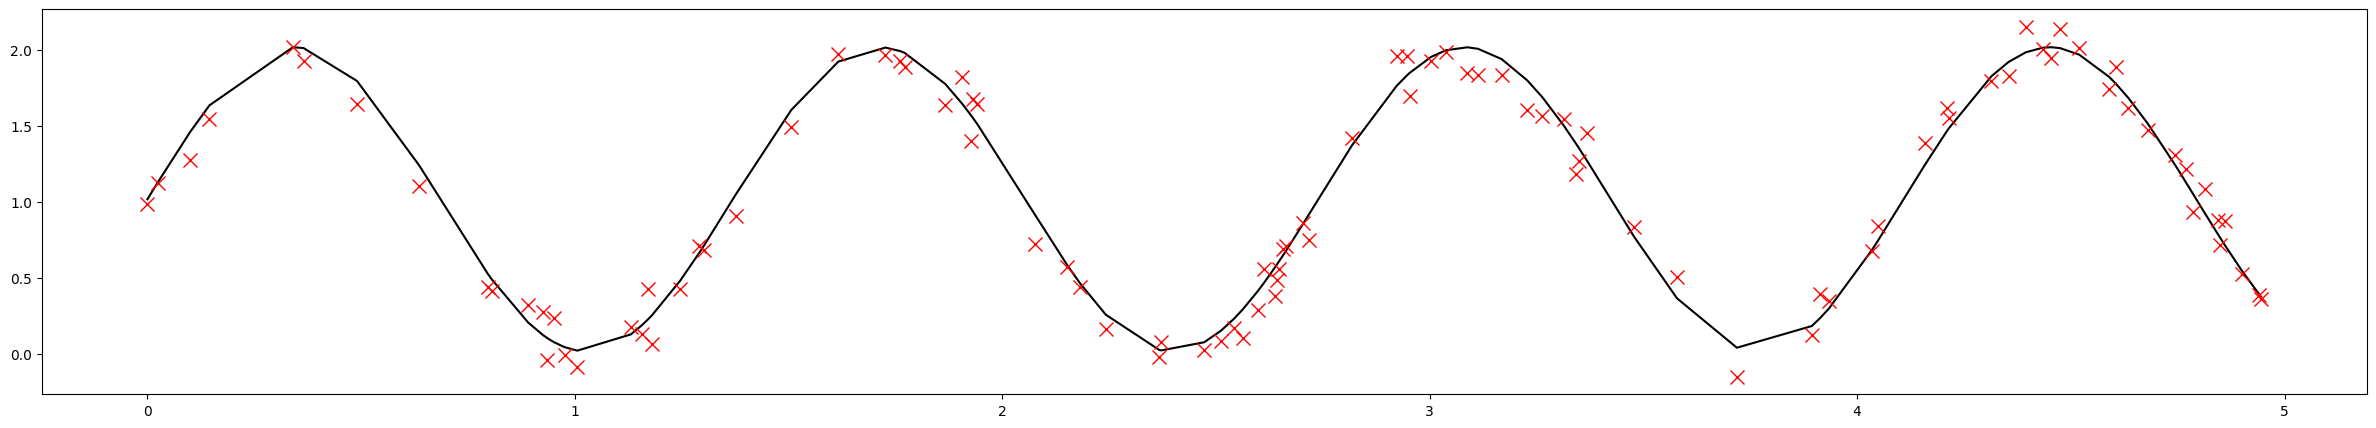

In [3]:
fig = plt.figure(figsize=(30,5))
index = 5
plt.plot(test_dataset[index,:,-1], test_GT[index,:,0], 'k-')
plt.plot(test_dataset[index,:,-1].cpu(), test_dataset[index,:,0].cpu(), 'rx', markersize=10)


In [ ]:
## Training
model = LatentNO_GRU(args, device)
#model = LNO_Ab1(args, device)
#model = LNO_Ab2(args, device)
#model = LNO_Ab3(args, device)
#model = LNO_Ab4(args, device)
#model = LNO_Ab5(args, device)
#model = Vanilla_DeepONet1(args, device)
#model = Vanilla_DeepONet2(args, device)
#model = Base_LODEGRU(args, device)
#model = Base_GRUDecay(args, device)
#model = Base_GRUVAE(args, device)
#model = Base_MLAE(args, device)


log_path = "logs/" + file_name + "_" + str(experimentID) + ".log"
if not os.path.exists("logs/"):
    utils.makedirs("logs/")
logger = get_logger(logpath=log_path, filepath='work/LNO_/LNO_1.0.ipynb')

optimizer = optim.Adamax(model.parameters(), lr = args.lr)

num_batches = len(train_dataloader)

for itr in range(1, num_batches * (args.niters + 1)):
    optimizer.zero_grad()
    update_learning_rate(optimizer, decay_rate = 0.999, lowest = args.lr / 10)
    
    wait_until_kl_inc = 10
    if itr // num_batches < wait_until_kl_inc:
        kl_coef = 0.
    else:
        kl_coef = (1-0.99** (itr // num_batches - wait_until_kl_inc))
    
    try:
        batch = next(train_dataloader_iter)
    except StopIteration:
        train_dataloader_iter = iter(train_dataloader)
        batch = next(train_dataloader_iter)
        
    train_res, pred_y = model.compute_all_losses(batch, kl_coef = kl_coef)
    train_res["loss"].backward()
    optimizer.step()
    
    n_iters_to_viz = 1
    if itr % (n_iters_to_viz * num_batches) == 0:
        with torch.no_grad():
            model.TestInfo(experimentID, test_dataset.to(device), train_res, itr, num_batches, kl_coef, logger)

        torch.save({'args': args,'state_dict': model.state_dict(),}, ckpt_path)

torch.save({'args': args,'state_dict': model.state_dict(),}, ckpt_path)


In [6]:
## testing
model = LatentNO_GRU(args, device)
model.load_state_dict(torch.load('experiments/experiment_{}.ckpt'.format(experimentID))['state_dict'])

batch = test_dataset[:10]
batch_GT = test_GT[:10]
pred_y = model.test(batch.to(device)).cpu()

time_full = torch.linspace(0,5,200).unsqueeze(0).repeat(batch.shape[0],1)
pred_full = model.test_full(batch.to(device), time_full.to(device)).cpu()


In [7]:
batch = test_dataset[:10]
batch_GT = test_GT[:10]

exps = [10000, 301, 302, 302, 304, 500]
models = [LatentNO_GRU(args, device), Vanilla_DeepONet1(args, device), Base_GRUDecay(args, device),\
          Base_GRUVAE(args, device), Base_MLAE(args, device), Base_LODEGRU(args, device)]

preds = []
for i in range(len(exps)):
    models[i].load_state_dict(torch.load('experiments/experiment_{}.ckpt'.format(exps[i]))['state_dict'])
    pred_y = models[i].test(batch.to(device)).cpu()
    preds.append(pred_y)
    

RuntimeError: Error(s) in loading state_dict for Base_GRUVAE:
	Unexpected key(s) in state_dict: "rnn_cell_enc.decay.0.weight", "rnn_cell_enc.decay.0.bias", "rnn_cell_dec.decay.0.weight", "rnn_cell_dec.decay.0.bias". 
	size mismatch for rnn_cell_enc.weight_ih: copying a param with shape torch.Size([96, 2]) from checkpoint, the shape in current model is torch.Size([96, 3]).
	size mismatch for rnn_cell_dec.weight_ih: copying a param with shape torch.Size([96, 2]) from checkpoint, the shape in current model is torch.Size([96, 3]).

In [ ]:
index = 1
s_GT = test_GT[index]
s = batch[index,:,0]
t = batch[index,:,-1]

if len(pred_y.shape) == 4:
    ps = pred_y[0,index]
    ps_full = pred_full[0,index]
    msei = torch.mean((torch.mean(pred_y,axis=0)-batch_GT)**2)
else:
    ps = pred_y[index]
    ps_full = pred_full[index]
    msei = torch.mean((pred_y-batch_GT)**2)
print(msei)

fig = plt.figure(figsize=(30,5))
plt.plot(t, s, 'ko', markersize=8)
#plt.plot(t, s_GT, 'k-')
#plt.plot(time_full[index], ps_full, 'rx', markersize=5)
for i in range(len(exps)):
    pred_y = preds[i]
    if len(pred_y.shape) == 4:
        plt.plot(t, pred_y[0,index])
    else:
        plt.plot(t, pred_y[index])

plt.savefig("results/{}.png".format(experimentID))
